# Inflation Regime Detection

Inflation regime detection is one of the powerful macro intelligence tool. It is considered as a powerful tool because its specifically  distinguishing between low and high inflation environtments. Regime detection itself is a powerful analytical tool because economic, behavioral and market dynamics change fundamentally between them.

The purpose of this analytics is,
1. Analyze the trend inflation on each country
2. Comparing the inflation on each country
3. Analyze the CPI Distribution to find the stable and wild one
4. Analyze the volatility using standard deviation of each country

The method will be used in this analytics are K-Means and Regression.

The data that we will be use here is loaded a data that's published by IMF "https://data.imf.org/"

The reason why we will be using this data because of how powerful regime is as we already talk about it before. Then, we will turn it into something bigger that can be valuable once we are done with the regime

### Import Library

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math

from matplotlib.pyplot import xticks

%matplotlib inline

### Data Ingestion

In [3]:
file_path = "datasets/imf_cpi.csv"
df = pd.read_csv(file_path)
df.head(5)

,DATASET,SERIES_CODE,OBS_MEASURE,COUNTRY,INDEX_TYPE,COICOP_1999,TYPE_OF_TRANSFORMATION,FREQUENCY,SCALE,2014,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,IMF.STA:CPI(5.0.0),USA.CPI.CP10.IX.A,OBS_VALUE,United States,Consumer price index (CPI),Education,Index,Annual,Units,115.965034,...,123.531048,126.414146,129.312862,133.064108,135.681600,137.600269,142.521649,145.941673,150.605637,NaN
1,IMF.STA:CPI(5.0.0),USA.CPI.CP02.IX.A,OBS_VALUE,United States,Consumer price index (CPI),"Alcoholic beverages, tobacco and narcotics",Index,Annual,Units,108.171260,...,112.544172,116.500510,119.542920,123.429100,127.641880,133.336814,140.365196,147.078314,153.659773,NaN
2,IMF.STA:CPI(5.0.0),USA.CPI.CP10.POP_PCH_PA_PT.A,OBS_VALUE,United States,Consumer price index (CPI),Education,"Period average, Period-over-period percent change",Annual,Units,3.278435,...,2.808177,2.333906,2.293032,2.900907,1.967091,1.414096,3.576577,2.399653,3.195773,NaN
3,IMF.STA:CPI(5.0.0),USA.CPI.CP10.YOY_PCH_PA_PT.A,OBS_VALUE,United States,Consumer price index (CPI),Education,"Period average, Year-over-year (YOY) percent c...",Annual,Units,3.278435,...,2.808177,2.333906,2.293032,2.900907,1.967091,1.414096,3.576577,2.399653,3.195773,NaN
4,IMF.STA:CPI(5.0.0),USA.CPI.CP01.YOY_PCH_PA_PT.A,OBS_VALUE,United States,Consumer price index (CPI),Food and non-alcoholic beverages,"Period average, Year-over-year (YOY) percent c...",Annual,Units,2.407605,...,-1.325349,-0.202182,0.455565,0.885131,3.505030,3.469165,11.438885,4.944269,1.166140,NaN


As we have imported the data. So shape method will show us the dimension of the dataset.

In [4]:
print("Full train dataset shape is {}".format(df.shape))

Full train dataset shape is (884, 21)


This IMF CPI consist of 884 rows and 21 columns

### Data Preprocessing

In [5]:
df.dtypes

DATASET                    object
SERIES_CODE                object
OBS_MEASURE                object
COUNTRY                    object
INDEX_TYPE                 object
COICOP_1999                object
TYPE_OF_TRANSFORMATION     object
FREQUENCY                  object
SCALE                      object
2014                      float64
2015                      float64
2016                      float64
2017                      float64
2018                      float64
2019                      float64
2020                      float64
2021                      float64
2022                      float64
2023                      float64
2024                      float64
2025                      float64
dtype: object

In [6]:
object_cols = df.select_dtypes(include=['object']).columns
print("Categorical variables:", len(object_cols))

int_ = df.select_dtypes(include=['int64']).columns
print("Integer variables:", len(int_))

fl_cols = df.select_dtypes(include=['float64']).columns
print("Float variables:", len(fl_cols))


Categorical variables: 9
Integer variables: 0
Float variables: 12


### Initial EDA

In [7]:
df.info()
df.describe()
df.isna().sum()

# Filter and Copy Data
data = df[
    (df['TYPE_OF_TRANSFORMATION'] == 'Period average, Year-over-year (YOY) percent change') &
    (df['FREQUENCY'] == 'Annual')
].copy()

data.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 884 entries, 0 to 883
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   DATASET                 884 non-null    object 
 1   SERIES_CODE             884 non-null    object 
 2   OBS_MEASURE             884 non-null    object 
 3   COUNTRY                 884 non-null    object 
 4   INDEX_TYPE              884 non-null    object 
 5   COICOP_1999             884 non-null    object 
 6   TYPE_OF_TRANSFORMATION  884 non-null    object 
 7   FREQUENCY               884 non-null    object 
 8   SCALE                   884 non-null    object 
 9   2014                    715 non-null    float64
 10  2015                    726 non-null    float64
 11  2016                    748 non-null    float64
 12  2017                    761 non-null    float64
 13  2018                    787 non-null    float64
 14  2019                    718 non-null    fl

,DATASET,SERIES_CODE,OBS_MEASURE,COUNTRY,INDEX_TYPE,COICOP_1999,TYPE_OF_TRANSFORMATION,FREQUENCY,SCALE,2014,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
3,IMF.STA:CPI(5.0.0),USA.CPI.CP10.YOY_PCH_PA_PT.A,OBS_VALUE,United States,Consumer price index (CPI),Education,"Period average, Year-over-year (YOY) percent c...",Annual,Units,3.278435,...,2.808177,2.333906,2.293032,2.900907,1.967091,1.414096,3.576577,2.399653,3.195773,NaN
4,IMF.STA:CPI(5.0.0),USA.CPI.CP01.YOY_PCH_PA_PT.A,OBS_VALUE,United States,Consumer price index (CPI),Food and non-alcoholic beverages,"Period average, Year-over-year (YOY) percent c...",Annual,Units,2.407605,...,-1.325349,-0.202182,0.455565,0.885131,3.505030,3.469165,11.438885,4.944269,1.166140,NaN
5,IMF.STA:CPI(5.0.0),USA.CPI.CP08.YOY_PCH_PA_PT.A,OBS_VALUE,United States,Consumer price index (CPI),Communication,"Period average, Year-over-year (YOY) percent c...",Annual,Units,-0.049137,...,-0.550631,-5.483102,-1.265205,-0.536588,2.362062,1.817034,-0.430050,0.180603,-1.353980,NaN
10,IMF.STA:CPI(5.0.0),USA.CPI.CP03.YOY_PCH_PA_PT.A,OBS_VALUE,United States,Consumer price index (CPI),Clothing and footwear,"Period average, Year-over-year (YOY) percent c...",Annual,Units,0.395169,...,-0.022691,-0.373311,0.327138,-0.915604,-4.453169,2.394024,5.415234,2.684161,0.952374,NaN
12,IMF.STA:CPI(5.0.0),USA.CPI.CP04.YOY_PCH_PA_PT.A,OBS_VALUE,United States,Consumer price index (CPI),"Housing, water, electricity, gas and other fuels","Period average, Year-over-year (YOY) percent c...",Annual,Units,2.969430,...,2.847277,3.457183,3.162829,3.040952,2.588173,3.020479,6.895680,6.943748,5.105299,NaN


We filter the data to match the data we want which is the Year-On-Year CPI data and drop the unecessary data. We have to always check for the new shape again whenever we do something to the data and also dont forget to copy the data to prevent any damage to the original data.

In [8]:
print("New dataset shape is {}".format(data.shape))

New dataset shape is (241, 21)


### Data Cleaning and Aggregation

Proceed to data cleaning and aggregation or preparation process where we will drop every unnecessary data, clean every mess inside such as handling missing, duplicate, data types and even the row or column name. We also will check for the skewness, outliers, transformation and scaling here

In [9]:
cols_to_keep = ['COUNTRY'] + [col for col in df.columns if str(col).isdigit()]
data = data[cols_to_keep]
data.head(5)

,COUNTRY,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
3,United States,3.278435,3.614707,2.808177,2.333906,2.293032,2.900907,1.967091,1.414096,3.576577,2.399653,3.195773,NaN
4,United States,2.407605,1.167711,-1.325349,-0.202182,0.455565,0.885131,3.505030,3.469165,11.438885,4.944269,1.166140,NaN
5,United States,-0.049137,-1.700052,-0.550631,-5.483102,-1.265205,-0.536588,2.362062,1.817034,-0.430050,0.180603,-1.353980,NaN
10,United States,0.395169,-0.998736,-0.022691,-0.373311,0.327138,-0.915604,-4.453169,2.394024,5.415234,2.684161,0.952374,NaN
12,United States,2.969430,2.331401,2.847277,3.457183,3.162829,3.040952,2.588173,3.020479,6.895680,6.943748,5.105299,NaN


Handle Missing

In [10]:
data.replace("no data", np.nan, inplace=True)
data.head(5)

,COUNTRY,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
3,United States,3.278435,3.614707,2.808177,2.333906,2.293032,2.900907,1.967091,1.414096,3.576577,2.399653,3.195773,NaN
4,United States,2.407605,1.167711,-1.325349,-0.202182,0.455565,0.885131,3.505030,3.469165,11.438885,4.944269,1.166140,NaN
5,United States,-0.049137,-1.700052,-0.550631,-5.483102,-1.265205,-0.536588,2.362062,1.817034,-0.430050,0.180603,-1.353980,NaN
10,United States,0.395169,-0.998736,-0.022691,-0.373311,0.327138,-0.915604,-4.453169,2.394024,5.415234,2.684161,0.952374,NaN
12,United States,2.969430,2.331401,2.847277,3.457183,3.162829,3.040952,2.588173,3.020479,6.895680,6.943748,5.105299,NaN


Rename Column

In [11]:
data.rename(columns={data.columns[0]: 'Country'}, inplace=True)
data.head()

,Country,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
3,United States,3.278435,3.614707,2.808177,2.333906,2.293032,2.900907,1.967091,1.414096,3.576577,2.399653,3.195773,NaN
4,United States,2.407605,1.167711,-1.325349,-0.202182,0.455565,0.885131,3.505030,3.469165,11.438885,4.944269,1.166140,NaN
5,United States,-0.049137,-1.700052,-0.550631,-5.483102,-1.265205,-0.536588,2.362062,1.817034,-0.430050,0.180603,-1.353980,NaN
10,United States,0.395169,-0.998736,-0.022691,-0.373311,0.327138,-0.915604,-4.453169,2.394024,5.415234,2.684161,0.952374,NaN
12,United States,2.969430,2.331401,2.847277,3.457183,3.162829,3.040952,2.588173,3.020479,6.895680,6.943748,5.105299,NaN


The dataset is currently in a wide format, where each year is stored as a separate column. This structure makes it difficult to perform time-series analysis, aggregation, and visualization efficiently.

To address this, we reshape the data into a long format by consolidating all year columns into a single Year column, with corresponding values stored in Inflation_YoY.

This transformation standardizes the dataset, making it easier to analyze trends over time, apply group operations, and build visualizations.

In [12]:
data_long = data.melt(
    id_vars=['Country'],
    var_name='Year',
    value_name='Inflation_YOY'
)

Convert Type Data

In [13]:
data_long['Year'] = pd.to_numeric(data_long['Year'], errors='coerce')
data_long['Inflation_YOY'] = pd.to_numeric(data_long['Inflation_YOY'], errors='coerce')

Drop Missing

In [14]:
data_long = data_long.dropna()

In [15]:
data_long.head(4)

,Country,Year,Inflation_YOY
0,United States,2014,3.278435
1,United States,2014,2.407605
2,United States,2014,-0.049137
3,United States,2014,0.395169


This data is still currently showing the inflation rate of each classification of individual consumption according to purpose (COICOP). This structure makes it hard to determine which data will we use to analyze.

Therefore, we have to take the mean as it representation make it easier to analyze.

In [16]:
data_long = (
    data_long.groupby(['Country', 'Year'])['Inflation_YOY']
    .mean()
    .reset_index()
)

print(data_long[data_long['Country'] == "Argentina"])

     Country  Year  Inflation_YOY
0  Argentina  2018      33.594068
1  Argentina  2019      51.922107
2  Argentina  2020      41.320904
3  Argentina  2021      45.824785
4  Argentina  2022      69.130496
5  Argentina  2023     129.759611
6  Argentina  2024     226.218189
7  Argentina  2025      45.207520


### Add Region

Since this data only shown the country, we also want to add the continent region based on the country.

In [17]:
# Add Region
region_map = {
    'United States': 'North America',
    'Canada': 'North America',
    'Mexico': 'North America',
    'Argentina': 'South America',
    'Brazil': 'South America',
    'Chile': 'South America',
    'France': 'Europe',
    'Germany': 'Europe',
    'United Kingdom': 'Europe',
    'Russian Federation': 'Europe',
    'Türkiye, Republic of': 'Europe',
    "China, People's Republic of": 'Asia',
    'India': 'Asia',
    'Indonesia': 'Asia',
    'Japan': 'Asia',
    'Saudi Arabia': 'Asia',
    'Egypt, Arab Republic of': 'Africa',
    'Kenya': 'Africa',
    'Nigeria': 'Africa',
    'South Africa': 'Africa',
    'Australia': 'Oceania',
    'New Zealand': 'Oceania',
}

data_long['Region'] = data_long['Country'].map(region_map)

# Reorder columns
data_long = data_long[['Country', 'Region', 'Year', 'Inflation_YOY']]

# Sanity check
print(data_long['Region'].isna().sum(), "unmapped countries")
data_long.head(4)

0 unmapped countries


,Country,Region,Year,Inflation_YOY
0,Argentina,South America,2018,33.594068
1,Argentina,South America,2019,51.922107
2,Argentina,South America,2020,41.320904
3,Argentina,South America,2021,45.824785


### Descriptive Analysis

In [18]:
data_long.describe()

,Year,Inflation_YOY
count,259.000000,259.000000
mean,2019.540541,7.768295
std,3.436198,18.722962
min,2014.000000,-7.800385
25%,2017.000000,1.912367
50%,2020.000000,3.635969
75%,2022.500000,6.379025
max,2025.000000,226.218189


In [19]:
data_long.groupby('Country')['Inflation_YOY'].agg(['mean', 'std', 'min', 'max']).round(2).sort_values('mean', ascending=False)

,mean,std,min,max
Country,,,,
Argentina,80.37,66.32,33.59,226.22
"Türkiye, Republic of",25.37,21.46,7.52,61.97
Nigeria,16.89,7.24,8.05,33.24
"Egypt, Arab Republic of",14.56,7.84,5.45,28.19
Russian Federation,7.13,3.64,3.31,13.86
Brazil,5.65,2.15,3.21,9.28
India,5.02,1.25,2.40,6.70
Chile,4.61,2.64,2.18,11.64
Kenya,4.47,0.79,3.04,5.90


To compare inflation behavior across countries, we summarize the average level, volatility, and extreme values of inflation.

The results reveal a clear disparity between countries with moderate inflation and those experiencing extreme inflation conditions. Argentina stands out with an exceptionally high average inflation (~80%) and extreme volatility, indicating severe macroeconomic instability.

In contrast, countries such as India, Brazil, and Mexico maintain moderate inflation levels (around 4–5%) with significantly lower volatility, reflecting more stable economic conditions.

In [20]:
data_long.groupby('Region')['Inflation_YOY'].agg(['mean', 'std', 'min', 'max']).round(2).sort_values('mean', ascending=False)

,mean,std,min,max
Region,,,,
South America,23.94,45.75,2.18,226.22
Africa,9.74,8.25,-7.80,33.24
Europe,7.85,13.11,0.19,61.97
North America,2.82,1.68,0.21,6.82
Asia,2.50,2.21,-6.43,6.70
Oceania,2.44,1.73,0.46,6.59


To compare inflation behavior across the region, we did the same as we did before on the country session.

The result reveal a clear disparity between region with moderate inflation and those experiencing high inflation conditions. South Africa stands out with an exceptionally extreme average inflation (~23.94%) and extreme volatility, indicating severe macroeconomic instability.

Then we have Africa and Europe stands in a high inflation level (around 7–10%) with high volatility, indicate an unpredictable swing of inflation.

In contrast, regions such as North America, Asia, and Oceania maintainmoderate inflation levels (around 2–3%) with significantly lower volatility, reflecting more stable economic conditions.

## Inflation Rate Trend

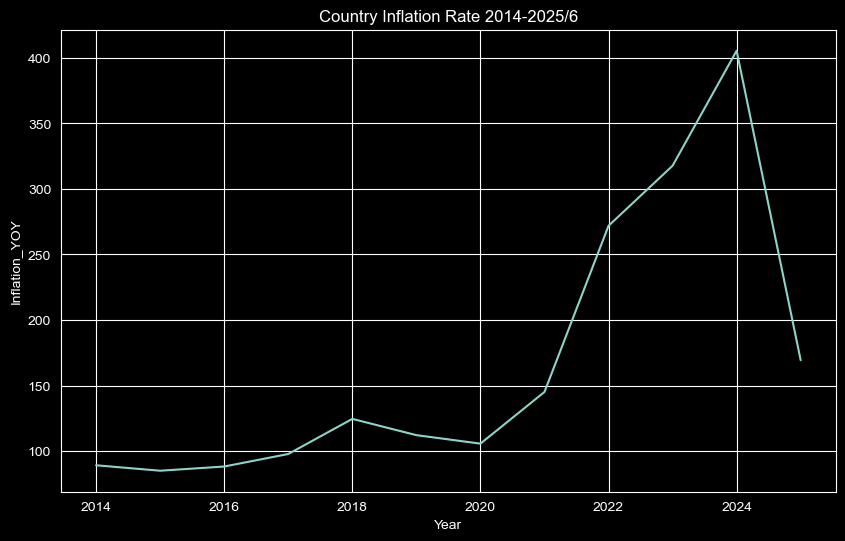

In [21]:

plt.figure(figsize=(10, 6))
data_long.groupby('Year')['Inflation_YOY'].sum().plot()
plt.xlabel('Year')
plt.ylabel('Inflation_YOY')
plt.title('Country Inflation Rate 2014-2025/6')
plt.show()


The visualization shows a sharp spike in average inflation around 2022–2024, reaching extremely high levels. However, this surge is not representative of most countries and is likely driven by extreme outliers, particularly countries experiencing hyperinflation.

For the majority of countries, inflation remains within a moderate range, indicating that the apparent spike in the average is heavily skewed by a small number of economies.

This highlights a key limitation of using the mean in cross-country analysis, where extreme values can distort the overall trend and lead to misleading conclusions.

## Country's Inflation Rate Comparison

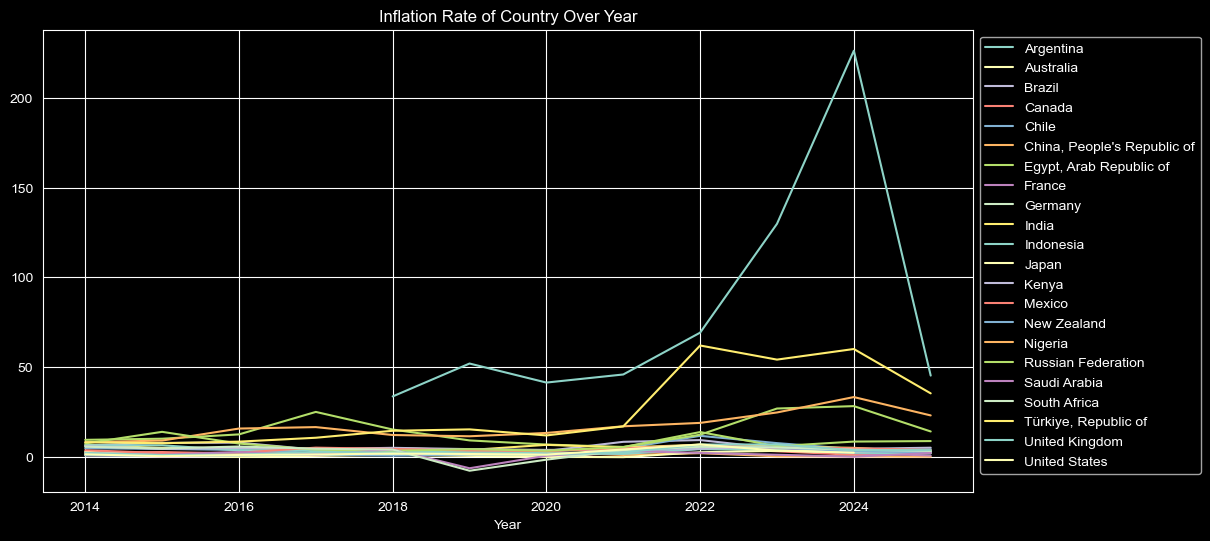

In [22]:
data_long.groupby(['Year', 'Country'])['Inflation_YOY'].sum().unstack().plot(figsize=(12, 6))
plt.title('Inflation Rate of Country Over Year')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

The visualization highlights a clear divergence in inflation dynamics across countries. Argentina stands out as a significant outlier, experiencing extreme inflation spikes between 2022 and 2024, far exceeding all other countries.

In contrast, most countries remain within a moderate inflation range, with noticeable increases around 2021–2023, likely reflecting global economic shocks following the COVID-19 period. Countries such as Nigeria and South Africa exhibit higher-than-average inflation but remain significantly below extreme cases like Argentina.

Overall, the chart suggests that while inflation pressures were globally synchronized during the post-pandemic period, their severity varied substantially across countries, with only a few experiencing extreme instability.

### Region's  Inflation Rate Comparison

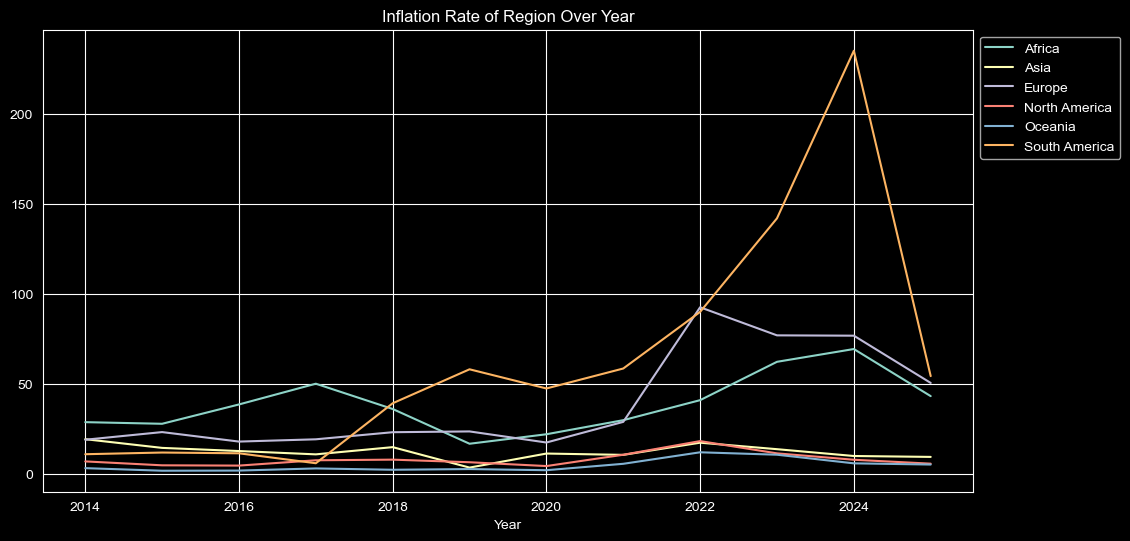

In [23]:
## Country's Inflation Rate Comparison
data_long.groupby(['Year', 'Region'])['Inflation_YOY'].sum().unstack().plot(figsize=(12, 6))
plt.title('Inflation Rate of Region Over Year')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

The visualization highlights a clear divergence in inflation dynamics across continents. South America stands out as a significant outlier, experiencing extreme inflation spikes between 2022 and 2024, far exceeding all other countries.

In contrast, most region remain within a moderate inflation range, with noticeable increases around 2021–2023, likely reflecting global economic shocks following the COVID-19 period. Region such as Europe and Africa exhibit higher-than-average inflation but remain significantly below extreme cases like Argentina.

Overall, the chart suggests that while inflation pressures were globally synchronized during the post-pandemic period, their severity varied substantially across Region, with only a few experiencing extreme instability.

### Volatility

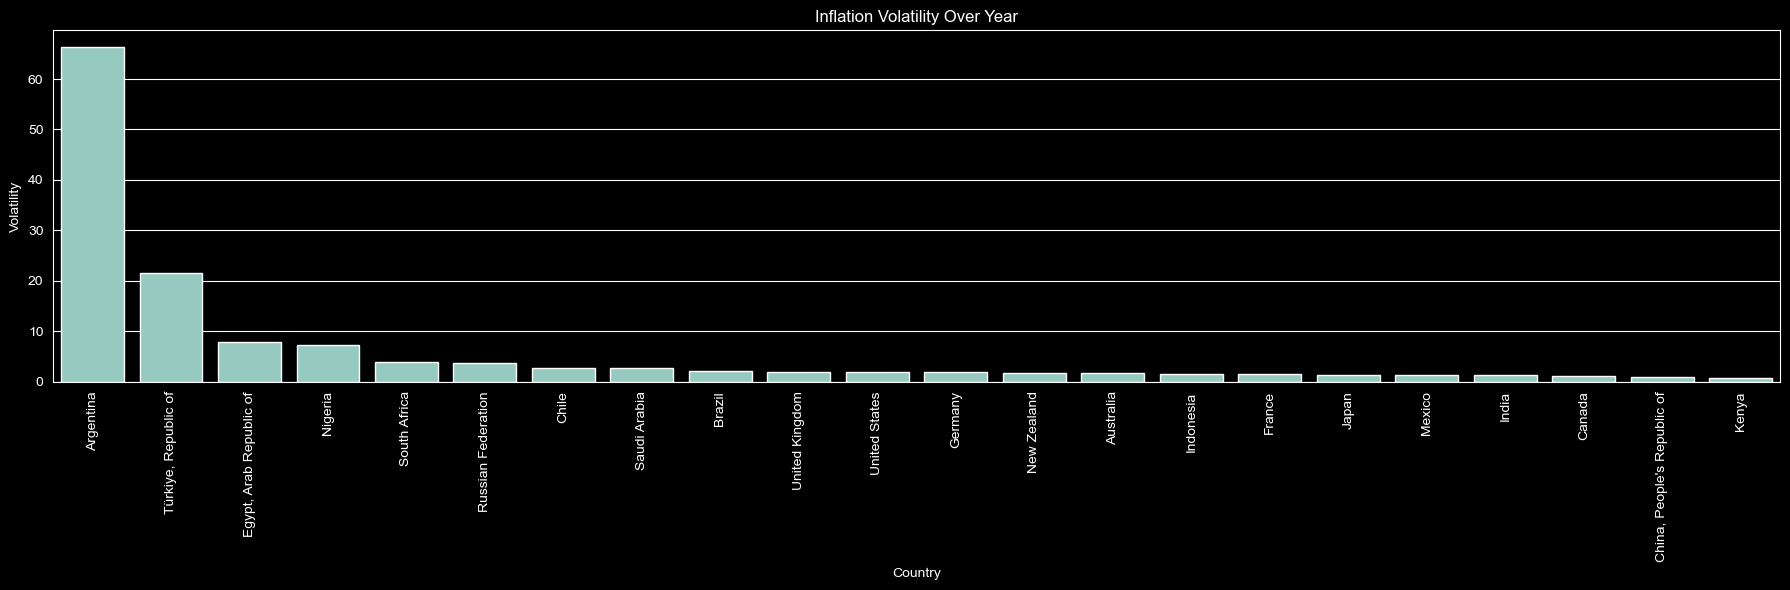

In [25]:
volatility = data_long.groupby('Country')['Inflation_YOY'].std().reset_index()
volatility.columns = ['Country', 'Volatility']
volatility = volatility.sort_values('Volatility', ascending=False)

plt.figure(figsize=(18, 6))
sns.barplot(data=volatility, x='Country', y='Volatility')
plt.xticks(rotation=90)
plt.title('Inflation Volatility Over Year')
plt.tight_layout()
plt.show()

Argentina dominates volatility with a std dev of ~65, nearly 3x higher than Turkey
in second place. This suggests Argentina experienced extreme and erratic inflation
swings, consistent with its well-documented hyperinflation episodes. The majority
of countries cluster near zero, indicating stable inflation over the observed period.

In [ ]:
### CPI Distribution per Country

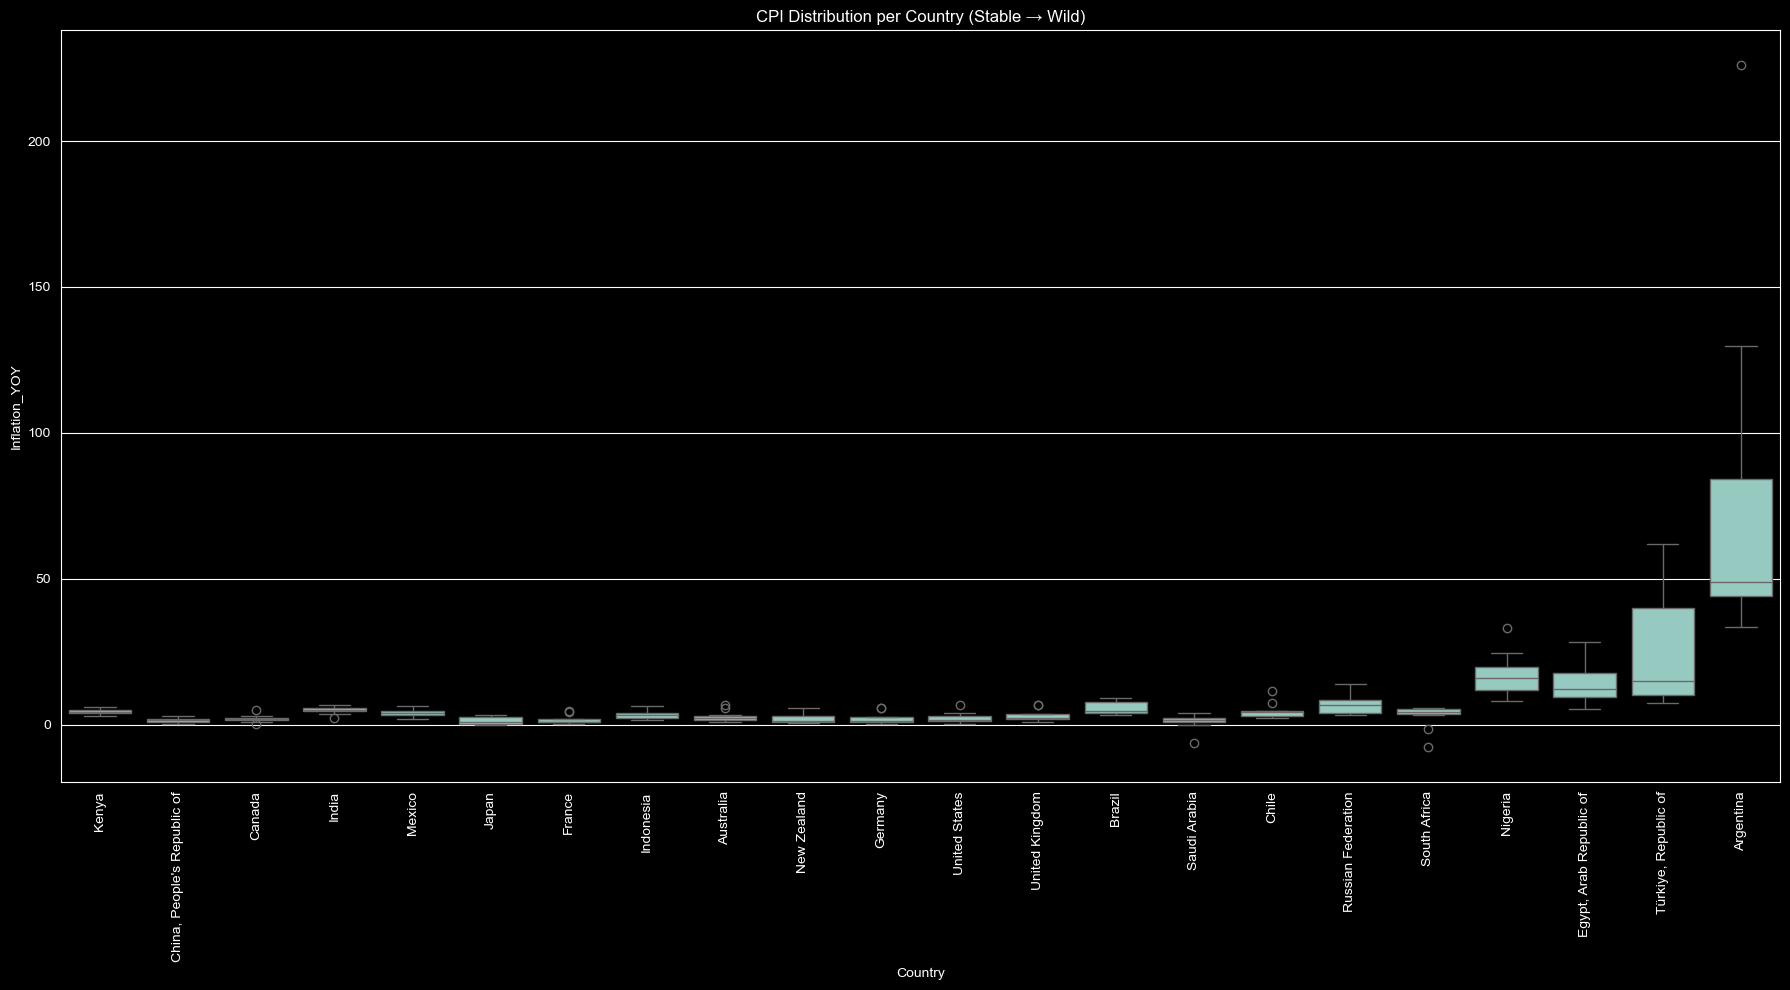

In [27]:
plt.figure(figsize=(18, 10))
order = data_long.groupby('Country')['Inflation_YOY'].std().sort_values().index
sns.boxplot(data=data_long, x='Country', y='Inflation_YOY', order=order)
plt.xticks(rotation=90)
plt.title('CPI Distribution per Country (Stable → Wild)')
plt.tight_layout()
plt.show()

The boxplot confirms a clear separation between stable and wild economies.
Most countries cluster near zero with tight IQRs, indicating consistent and
predictable inflation. Argentina stands as the extreme outlier — its box spans
~30 to ~85% with a data point reaching 226%, characteristic of hyperinflation.
Turkey and Egypt also show noticeably wider distributions compared to the rest.

## Modelling